# 03 - Correlation Matrices Dataset (PyTorch)
In this notebook we build a PyTorch dataset of correlation matrices computed on rolling windows of log-returns.

Starting from the cleaned quotation matrix (filtered_data.csv), we first compute logarithmic returns and then compute rolling-window correlation matrices on those returns.
- Correlation is computed on log-returns.
- The first day is removed because a return cannot be computed for the first observation.

Log-return formula:
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

To compute how many samples (i.e., windows/correlation matrices) you will obtain from your dataset, the formula is straightforward.

Let:
- $N$: total number of rows (days) in the log-returns dataset.
- $W$: window size (`WINDOW_LENGTH`).
- $S$: step between consecutive windows (`STRIDE`).

The formula for the number of windows $N_{windows}$ is:

$$
N_{windows} = \left\lfloor \frac{N - W}{S} \right\rfloor + 1
$$

In [14]:
from pathlib import Path
from typing import List, Tuple
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

In [15]:
# Editable parameters
DATA_PATH = Path('../data/processed/filtered_data.csv')
WINDOW_LENGTH = 60
STRIDE = 1
DTYPE = torch.float32

df = pd.read_csv(DATA_PATH)

print(f'Input price matrix shape (days, assets): {df.shape}')
print(f'Log-returns rows available after dropping first day: {df.shape[0] - 1}')
df.head()

Input price matrix shape (days, assets): (1258, 333)
Log-returns rows available after dropping first day: 1257


,BBY,CSCO,TSN,KMI,GT,DLTR,IVZ,PFE,GD,EQR,...,XEL,IR,CCI,DUK,JEC,NUE,BIIB,MSI,RHT,VMC
0,14.313087,17.893888,21.696400,30.784206,12.417879,45.185,23.100399,23.138992,61.404850,40.617558,...,24.195093,38.409443,61.060830,57.073170,48.313774,39.015694,166.34,56.243200,50.81,49.740070
1,14.967250,17.872437,22.184496,30.941988,12.393971,46.110,23.134890,23.155901,61.188030,40.838947,...,24.203524,37.884186,61.358260,57.073170,47.482826,38.426777,168.70,56.080463,51.58,50.775303
2,15.499302,17.795216,22.213210,31.174510,12.116636,46.480,23.678123,23.409525,60.564674,41.067715,...,24.532307,38.000908,62.084343,57.452282,47.769703,38.989710,169.96,56.505386,52.08,50.882732
3,16.048800,18.205347,22.328054,31.108076,12.240958,46.000,23.885070,23.730783,61.133823,41.429317,...,24.641901,38.839863,62.635464,57.823154,49.490955,39.327473,171.31,56.930305,51.99,52.435585
4,16.354074,18.631780,22.557747,30.701162,12.336591,45.470,23.954052,23.773054,61.142860,41.591670,...,24.532307,38.985767,63.099106,57.592392,49.698692,40.262810,172.45,57.056877,52.80,52.250023


In [16]:
def build_correlation_windows(
    frame: pd.DataFrame,
    window_length: int,
    stride: int = 1,
    dtype: torch.dtype = torch.float32
) -> Tuple[torch.Tensor, List[Tuple[int, int]]]:
    
    # Compute log-returns: ln(P_t / P_{t-1}) and drop the first day (NaN by construction).
    log_returns = np.log(frame / frame.shift(1)).iloc[1:].copy()
    
    # Check if there are enough rows for the sliding window
    n_rows = len(log_returns)
    if n_rows < window_length:
        raise ValueError(
            f"Log-returns dataset too short ({n_rows} rows) for a window_length of {window_length}"
        )

    corr_mats = []
    windows = []

    # Iterate through time windows on log-returns
    for start in range(0, n_rows - window_length + 1, stride):
        end = start + window_length
        
        # .corr() defaults to Pearson correlation between columns
        window_corr = log_returns.iloc[start:end].corr()
        
        # Convert to PyTorch Tensor
        corr_mats.append(torch.tensor(window_corr.values, dtype=dtype))
        windows.append((start, end))

    # Return the full stack (stack converts the list into a single 3D tensor)
    return torch.stack(corr_mats), windows

In [17]:
class RollingCorrelationDataset(Dataset):
    def __init__(
        self,
        frame: pd.DataFrame,
        window_length: int,
        stride: int = 1,
        dtype: torch.dtype = torch.float32,
    ) -> None:
        self.tensor, self.window_ranges = build_correlation_windows(
            frame=frame,
            window_length=window_length,
            stride=stride,
            dtype=dtype,
        )

    def __len__(self) -> int:
        return self.tensor.size(0)

    def __getitem__(self, idx: int):
        corr = self.tensor[idx]
        start, end = self.window_ranges[idx]
        return {
            'corr': corr,
            'window_start': start,
            'window_end': end,
        }

In [18]:
dataset = RollingCorrelationDataset(
    frame=df,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    dtype=DTYPE,
    )

print(f'Number of windows: {len(dataset)}')
print(f'Single element shape: {dataset[0]["corr"].shape}')
print(f'Full tensor shape: {dataset.tensor.shape}')

sample = dataset[0]
sample

Number of windows: 1198
Single element shape: torch.Size([333, 333])
Full tensor shape: torch.Size([1198, 333, 333])


{'corr': tensor([[1.0000, 0.0125, 0.2367,  ..., 0.2397, 0.1579, 0.3954],
         [0.0125, 1.0000, 0.0814,  ..., 0.3523, 0.3383, 0.2410],
         [0.2367, 0.0814, 1.0000,  ..., 0.1466, 0.2947, 0.4064],
         ...,
         [0.2397, 0.3523, 0.1466,  ..., 1.0000, 0.3363, 0.2859],
         [0.1579, 0.3383, 0.2947,  ..., 0.3363, 1.0000, 0.4626],
         [0.3954, 0.2410, 0.4064,  ..., 0.2859, 0.4626, 1.0000]]),
 'window_start': 0,
 'window_end': 60}

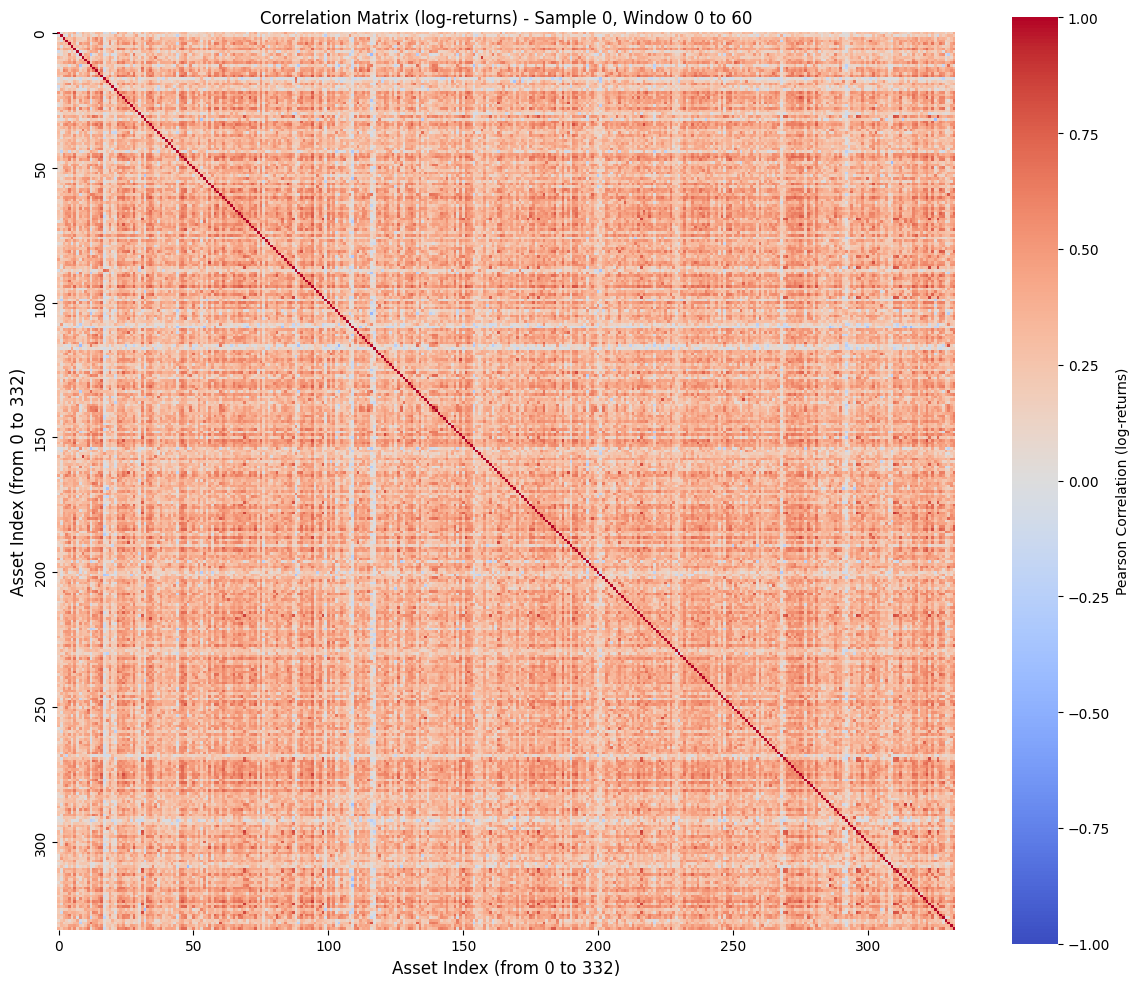

In [19]:
# Extract and convert correlation matrix to numpy
idx_sample = 0
corr_matrix = dataset[idx_sample]["corr"].numpy()
num_assets = corr_matrix.shape[0]

plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(
    corr_matrix, 
    annot=False, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    square=True,
    xticklabels=50, 
    yticklabels=50,
    cbar_kws={'label': 'Pearson Correlation (log-returns)'}
)

plt.title(f'Correlation Matrix (log-returns) - Sample {idx_sample}, Window {dataset[idx_sample]["window_start"]} to {dataset[idx_sample]["window_end"]}')
plt.xlabel('Asset Index (from 0 to 332)', fontsize=12)
plt.ylabel('Asset Index (from 0 to 332)', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
print(dataset[0]["corr"][0:10,0:10])

tensor([[ 1.0000,  0.0125,  0.2367,  0.1335,  0.2778,  0.2206,  0.3993, -0.1091,  0.1194,  0.3455],
        [ 0.0125,  1.0000,  0.0814, -0.0263,  0.3640, -0.0430,  0.2290,  0.0640,  0.0324,  0.2722],
        [ 0.2367,  0.0814,  1.0000,  0.3582,  0.2636,  0.2957,  0.4246,  0.2250,  0.2136,  0.1599],
        [ 0.1335, -0.0263,  0.3582,  1.0000,  0.3432,  0.1902,  0.4402,  0.1824,  0.1806,  0.1956],
        [ 0.2778,  0.3640,  0.2636,  0.3432,  1.0000,  0.2732,  0.3967,  0.0294,  0.5335,  0.3689],
        [ 0.2206, -0.0430,  0.2957,  0.1902,  0.2732,  1.0000,  0.2755,  0.2719,  0.1753,  0.3121],
        [ 0.3993,  0.2290,  0.4246,  0.4402,  0.3967,  0.2755,  1.0000,  0.0603,  0.3121,  0.3633],
        [-0.1091,  0.0640,  0.2250,  0.1824,  0.0294,  0.2719,  0.0603,  1.0000, -0.0808,  0.0920],
        [ 0.1194,  0.0324,  0.2136,  0.1806,  0.5335,  0.1753,  0.3121, -0.0808,  1.0000,  0.1201],
        [ 0.3455,  0.2722,  0.1599,  0.1956,  0.3689,  0.3121,  0.3633,  0.0920,  0.1201,  1.0000]])

In [21]:
#  Save of the correlation tensor
OUTPUT_TENSOR_PATH = Path(f'../data/processed/corr_windows_tensor_{WINDOW_LENGTH}_{STRIDE}.pt')
torch.save(
    {
        'corr_tensor': dataset.tensor,
        'window_ranges': dataset.window_ranges,
        'window_length': WINDOW_LENGTH,
        'stride': STRIDE,
        'input_type': 'log_returns',
        'tickers': df.columns.tolist(),
    },
    OUTPUT_TENSOR_PATH,
    )

print(f'Tensor saved to: {OUTPUT_TENSOR_PATH.resolve()}')
print('\n--- Saved Output Structure ---')
print(f"corr_tensor shape: {dataset.tensor.shape}")
print(f"  - Dimension 0 (num_windows): {dataset.tensor.shape[0]} rolling windows")
print(f"  - Dimension 1 (num_assets): {dataset.tensor.shape[1]} assets")
print(f"  - Dimension 2 (num_assets): {dataset.tensor.shape[2]} assets (symmetric matrix)")
print(f"window_length: {WINDOW_LENGTH} days per window")
print(f"stride: {STRIDE} days between consecutive windows")
print("input_type: log_returns (ln(P_t / P_{t-1}))")
print(f"num_tickers: {len(df.columns)} tickers")
print(f"tickers: {df.columns.tolist()[:5]}... (showing first 5)")


Tensor saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\data\processed\corr_windows_tensor_60_1.pt

--- Saved Output Structure ---
corr_tensor shape: torch.Size([1198, 333, 333])
  - Dimension 0 (num_windows): 1198 rolling windows
  - Dimension 1 (num_assets): 333 assets
  - Dimension 2 (num_assets): 333 assets (symmetric matrix)
window_length: 60 days per window
stride: 1 days between consecutive windows
input_type: log_returns (ln(P_t / P_{t-1}))
num_tickers: 333 tickers
tickers: ['BBY', 'CSCO', 'TSN', 'KMI', 'GT']... (showing first 5)
